# 1. Outliers Removal

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the 2 files: the master file with all the outlier flags and the original dataset
# Original dataset (assuming it's in the same order as the master file)
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')
X = df.drop(columns=['sii'])
num_cols = X.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()

X = scaler.fit_transform(X)

X = pd.DataFrame(
    X,
    columns=num_cols,
    index=df.index
)


df_master = pd.read_csv('./Outliers/outliers_matrix.csv').set_index('row_id')

# 2. Identify columns that contain outlier flags (assuming they start with 'outlier_')
outlier_cols = [c for c in df_master.columns if c.startswith('outlier_')]

# 3. Calculate the mode for each row
# In a binary context (0/1), the mode is 1 if there are more 1s than 0s
# We use the .mode() method from pandas. If there's a tie, it returns both,

df_master['majority_outlier'] = df_master[outlier_cols].mode(axis=1)[0].astype(int)

# 4. Merge with the original dataset X
# If X doesn't have 'row_id' as the index, we assign it now (must be the same order)
if 'row_id' not in X.columns:
    X.index.name = 'row_id'

X_merged = X.join(df_master[['majority_outlier']])

# 5. Remove rows where the majority_outlier is 1
n_before = len(X_merged)
X_clean = X_merged[X_merged['majority_outlier'] == 0].drop(columns=['majority_outlier'])
n_after = len(X_clean)

print(f"Original dataset: {n_before} records")
print(f"Records removed (majority=1): {n_before - n_after}")
print(f"Clean dataset: {n_after} records")



Original dataset: 8460 records
Records removed (majority=1): 621
Clean dataset: 7839 records


## Save the cleaned dataset

In [9]:
# 6. Creation of the cleaned original dataset (sii included, not scaled data)
# We need to select the same rows from the original df that correspond to the clean indices in X_clean
df_clean = df.loc[X_clean.index]
# convert sii to int
df_clean['sii'] = df_clean['sii'].astype(int)

# 7. SAVE THE CLEANED DATASET
df_clean.to_csv('../dataset/cmi_internet_cleaned.csv', index=False)

print(f"Clean dataset dimensions: {df_clean.shape}")

# 8. Distribution of the target variable in the removed outliers
df_outliers_removed = df.loc[df_master[df_master['majority_outlier'] == 1].index]
print("Distribution of target in removed outliers:")
print(df_outliers_removed['sii'].value_counts())

# Percentage of outliers
# compute the percentage of outliers removed FROM EACH CLASS
record_counts_per_class = df['sii'].value_counts()
outliers_removed_per_class = df_outliers_removed['sii'].value_counts() # number of outliers removed per class
print("\nNumber of records removed from each class:")
print(outliers_removed_per_class)
percentage_outliers_removed = (outliers_removed_per_class / record_counts_per_class) * 100 # percentage of outliers removed per class
print("\nTotal records per class in original dataset:")
print(record_counts_per_class)
print("\nPercentage of outliers removed from each class:")
print(percentage_outliers_removed)



Clean dataset dimensions: (7839, 33)
Distribution of target in removed outliers:
sii
0.0    357
1.0    143
2.0    106
3.0     15
Name: count, dtype: int64

Number of records removed from each class:
sii
0.0    357
1.0    143
2.0    106
3.0     15
Name: count, dtype: int64

Total records per class in original dataset:
sii
0.0    5833
1.0    1587
2.0     952
3.0      88
Name: count, dtype: int64

Percentage of outliers removed from each class:
sii
0.0     6.120350
1.0     9.010712
2.0    11.134454
3.0    17.045455
Name: count, dtype: float64


# 2. Scaled Dataset Visualization

## Random projection

In [16]:
from sklearn import random_projection

# since it's random, we can have different results each time we run it. 
# Therefore, we select a random state to have the same results each time 
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=42)
X_rsp = rsp.fit_transform(X)

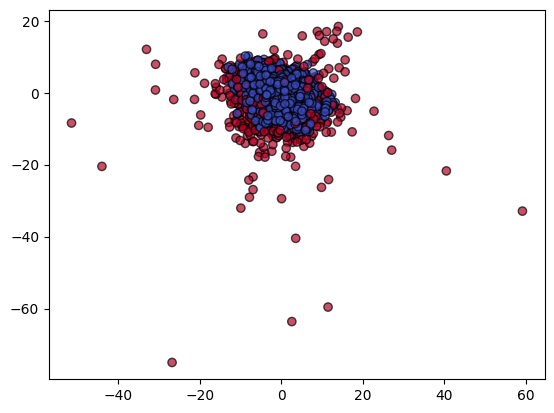

In [17]:
# label the points based on the majority_outlier column
labels = X_merged['majority_outlier'].values
plt.scatter(X_rsp[:, 0], X_rsp[:, 1], c=labels, cmap="coolwarm", edgecolor='k', alpha=0.7)
plt.show()

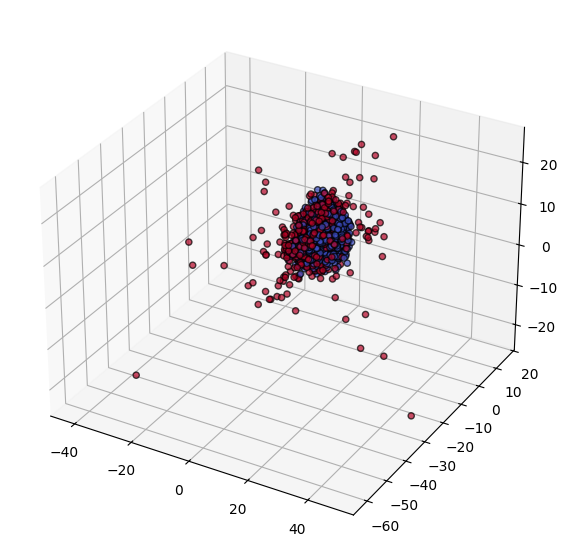

In [19]:
#doing random projection in 3D
from mpl_toolkits.mplot3d import Axes3D
rsp_3d = random_projection.GaussianRandomProjection(n_components=3, random_state=42)
X_rsp_3d = rsp_3d.fit_transform(X)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_rsp_3d[:, 0], X_rsp_3d[:, 1], X_rsp_3d[:, 2], c=labels, cmap="coolwarm", edgecolor='k', alpha=0.7)
#ax.set_title('3D Random Projection Colored by Majority Outlier Flag')
plt.show()

## PCA

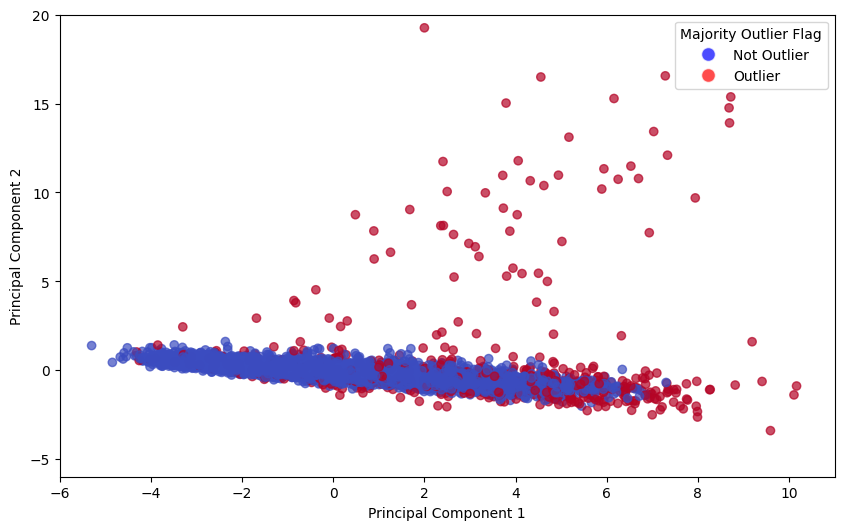

In [14]:
# PCA on the original dataset with flags on the outliers
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_merged.drop(columns=['majority_outlier']))
X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X_merged.index)
X_pca['majority_outlier'] = X_merged['majority_outlier']

plt.figure(figsize=(10, 6)) 
plt.scatter(X_pca['PC1'], X_pca['PC2'], c=X_pca['majority_outlier'], cmap='coolwarm', alpha=0.7)
#plt.title('PCA of Original Dataset with Outlier Flags')
plt.xlabel('Principal Component 1')
plt.xlim(-6,11)
plt.ylabel('Principal Component 2')
plt.ylim(-6,20)
# put a legend with custom labels
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Not Outlier', markerfacecolor='blue', markersize=10, alpha=0.7),
                   Line2D([0], [0], marker='o', color='w', label='Outlier', markerfacecolor='red', markersize=10, alpha=0.7)]
plt.legend(handles=legend_elements, title='Majority Outlier Flag', loc='upper right')
plt.show()


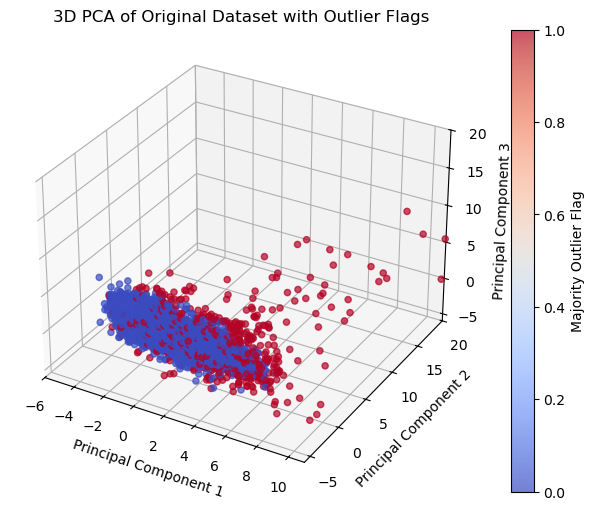

In [8]:
#do pca in 3d
from mpl_toolkits.mplot3d import Axes3D 
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_merged.drop(columns=['majority_outlier']))
X_pca_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'], index=X_merged.index)
X_pca_3d['majority_outlier'] = X_merged['majority_outlier']
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d['PC1'], X_pca_3d['PC2'], X_pca_3d['PC3'], c=X_pca_3d['majority_outlier'], cmap='coolwarm', alpha=0.7)
ax.set_title('3D PCA of Original Dataset with Outlier Flags')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_xlim(-6,11)
ax.set_ylim(-6,20)
ax.set_zlim(-6,20)
fig.colorbar(scatter, label='Majority Outlier Flag')
plt.show()


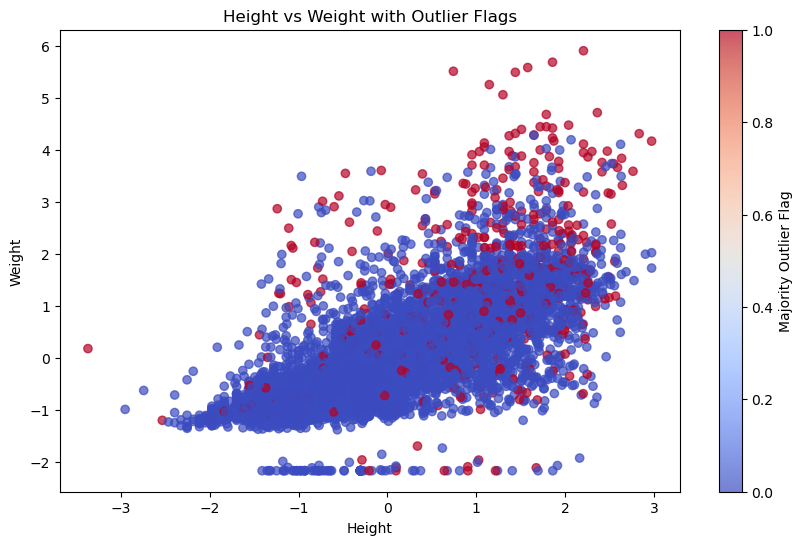

In [6]:
#trying to visualize the outliers and normal points in two meaningful variables, like height and weight
plt.figure(figsize=(10, 6))
plt.scatter(X_merged['Physical-Height'], X_merged['Physical-Weight'], c=X_merged['majority_outlier'], cmap='coolwarm', alpha=0.7)
plt.title('Height vs Weight with Outlier Flags')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.colorbar(label='Majority Outlier Flag')
plt.show()


## t-SNE

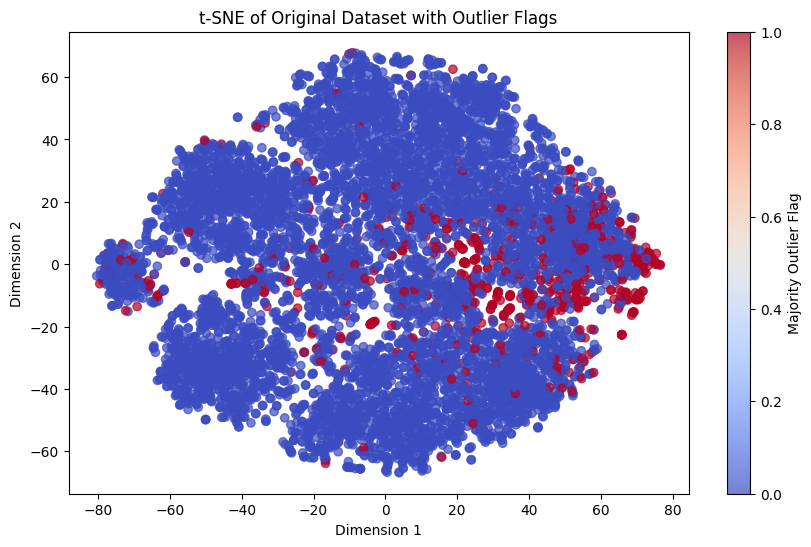

In [ ]:
# t-SNE on the original dataset with flags on the outliers
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_merged.drop(columns=['majority_outlier']))
X_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'], index=X_merged.index)
X_tsne['majority_outlier'] = X_merged['majority_outlier']
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne['Dim1'], X_tsne['Dim2'], c=X_tsne['majority_outlier'], cmap='coolwarm', alpha=0.7)
plt.title('t-SNE of Original Dataset with Outlier Flags')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.colorbar(label='Majority Outlier Flag')
plt.show()


In [ ]:
# t-SNE on the original dataset with flags on the outliers
from sklearn.manifold import TSNE
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(X_merged.drop(columns=['majority_outlier']))
X_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2', 'Dim3'], index=X_merged.index)
X_tsne['majority_outlier'] = X_merged['majority_outlier']


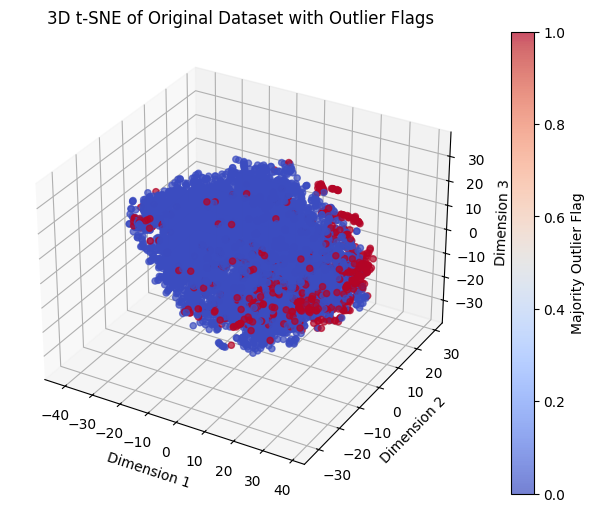

In [15]:

# Plotting the 3D t-SNE
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_tsne['Dim1'], X_tsne['Dim2'], X_tsne['Dim3'], c=X_tsne['majority_outlier'], cmap='coolwarm', alpha=0.7)
ax.set_title('3D t-SNE of Original Dataset with Outlier Flags')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
fig.colorbar(scatter, label='Majority Outlier Flag')
plt.show()
